# Fine-tuning a Vision Transformer on CIFAR-10

We fine-tune a pretrained **ViT-B/16** (86M parameters) on CIFAR-10 (10 classes).  
Two strategies are compared:
1. **Linear probing** — freeze the entire backbone, train only the classification head.
2. **Full fine-tuning** — unfreeze all parameters, use a much smaller learning rate.

## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

from torchvision.models import vit_b_16, ViT_B_16_Weights

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [3]:
weights = ViT_B_16_Weights.DEFAULT

transform = weights.transforms()

In [12]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

## 2. Load CIFAR-10 & Prepare DataLoaders

ViT-B/16 expects 224×224 input, so the pretrained transforms handle resizing.  
CIFAR-10 images are originally 32×32 — they get upscaled automatically.

Below we also load the model and replace its head for 10-class classification.

In [5]:
model = vit_b_16(weights=weights)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 234MB/s]


## 3. Load Pretrained ViT-B/16 & Replace Head

Load the model with ImageNet-1K pretrained weights, then replace the classification
head (originally 1000 classes → 10 classes for CIFAR-10).

### Replace the classification head (1000 → 10 classes)

In [6]:
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, 10)
model = model.to(device)
print(f"Model on: {device}")
print(f"Head: {model.heads.head}")

Model on: cuda
Head: Linear(in_features=768, out_features=10, bias=True)


## 4. Linear Probing

Freeze all transformer parameters (`requires_grad=False`), keep only the new head
trainable. This tests how good the pretrained features already are for our task.

In [7]:
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True

### Loss function & optimizer

Use cross-entropy loss. Since only the head is trainable, we pass only
`model.heads.parameters()` to the optimizer with a relatively high learning rate (1e-3).

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.heads.parameters(), lr=1e-3)

### Training & evaluation utilities

In [9]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total

    return total_loss / len(loader), acc

In [10]:
def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

### Train linear probe (5 epochs)

In [13]:
linear_probe_history = {"train_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(10):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_acc = evaluate(model, test_loader)

    linear_probe_history["train_loss"].append(train_loss)
    linear_probe_history["train_acc"].append(train_acc)
    linear_probe_history["val_acc"].append(val_acc)

    print(f"[Linear Probe] Epoch {epoch+1}/5 | "
          f"Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print(f"\nLinear probing final val accuracy: {linear_probe_history['val_acc'][-1]:.2f}%")

[Linear Probe] Epoch 1/5 | Loss: 0.0915 | Train Acc: 97.01% | Val Acc: 95.25%
[Linear Probe] Epoch 2/5 | Loss: 0.0893 | Train Acc: 97.06% | Val Acc: 95.29%
[Linear Probe] Epoch 3/5 | Loss: 0.0884 | Train Acc: 97.15% | Val Acc: 95.23%
[Linear Probe] Epoch 4/5 | Loss: 0.0876 | Train Acc: 97.17% | Val Acc: 95.29%
[Linear Probe] Epoch 5/5 | Loss: 0.0867 | Train Acc: 97.12% | Val Acc: 95.34%
[Linear Probe] Epoch 6/5 | Loss: 0.0852 | Train Acc: 97.19% | Val Acc: 95.16%
[Linear Probe] Epoch 7/5 | Loss: 0.0845 | Train Acc: 97.20% | Val Acc: 94.96%
[Linear Probe] Epoch 8/5 | Loss: 0.0834 | Train Acc: 97.27% | Val Acc: 95.14%
[Linear Probe] Epoch 9/5 | Loss: 0.0824 | Train Acc: 97.30% | Val Acc: 95.10%
[Linear Probe] Epoch 10/5 | Loss: 0.0810 | Train Acc: 97.37% | Val Acc: 95.19%

Linear probing final val accuracy: 95.19%


## 5. Full Fine-Tuning

Unfreeze the entire model and train all parameters. We use a **much lower
learning rate** (1e-5 vs 1e-3) to avoid destroying the pretrained backbone
representations — this is critical to prevent catastrophic forgetting.

In [14]:
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Full fine-tuning: {trainable:,} / {total:,} parameters trainable ({100*trainable/total:.1f}%)")

Full fine-tuning: 85,806,346 / 85,806,346 parameters trainable (100.0%)


In [16]:
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

### Train full model (5 epochs)

In [17]:
finetune_history = {"train_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(5):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_acc = evaluate(model, test_loader)
    scheduler.step()

    finetune_history["train_loss"].append(train_loss)
    finetune_history["train_acc"].append(train_acc)
    finetune_history["val_acc"].append(val_acc)

    print(f"[Full FT] Epoch {epoch+1}/5 | "
          f"Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print(f"\nFull fine-tuning final val accuracy: {finetune_history['val_acc'][-1]:.2f}%")

[Full FT] Epoch 1/5 | Loss: 0.0714 | Train Acc: 97.58% | Val Acc: 97.00%
[Full FT] Epoch 2/5 | Loss: 0.0164 | Train Acc: 99.56% | Val Acc: 97.36%
[Full FT] Epoch 3/5 | Loss: 0.0041 | Train Acc: 99.96% | Val Acc: 97.54%
[Full FT] Epoch 4/5 | Loss: 0.0015 | Train Acc: 100.00% | Val Acc: 97.64%
[Full FT] Epoch 5/5 | Loss: 0.0011 | Train Acc: 100.00% | Val Acc: 97.65%

Full fine-tuning final val accuracy: 97.65%


## Comparison: Linear Probing vs Full Fine-Tuning

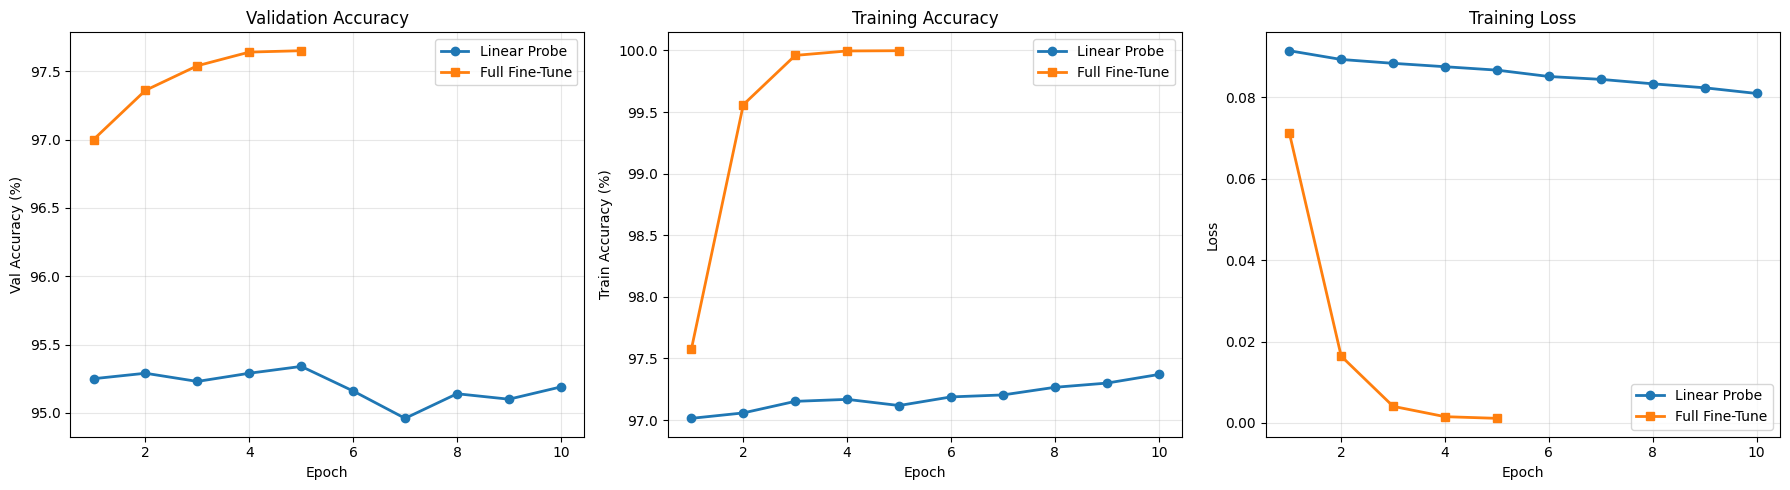


Method                 Final Val Acc Final Train Acc   Final Loss
-----------------------------------------------------------------
Linear Probe                  95.19%          97.37%       0.0810
Full Fine-Tune                97.65%         100.00%       0.0011


In [19]:
import matplotlib.pyplot as plt

epochs_lp = range(1, len(linear_probe_history["val_acc"]) + 1)
epochs_ft = range(1, len(finetune_history["val_acc"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Validation accuracy
axes[0].plot(epochs_lp, linear_probe_history["val_acc"], "o-", label="Linear Probe", lw=2)
axes[0].plot(epochs_ft, finetune_history["val_acc"], "s-", label="Full Fine-Tune", lw=2)
axes[0].set(xlabel="Epoch", ylabel="Val Accuracy (%)", title="Validation Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Training accuracy
axes[1].plot(epochs_lp, linear_probe_history["train_acc"], "o-", label="Linear Probe", lw=2)
axes[1].plot(epochs_ft, finetune_history["train_acc"], "s-", label="Full Fine-Tune", lw=2)
axes[1].set(xlabel="Epoch", ylabel="Train Accuracy (%)", title="Training Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Training loss
axes[2].plot(epochs_lp, linear_probe_history["train_loss"], "o-", label="Linear Probe", lw=2)
axes[2].plot(epochs_ft, finetune_history["train_loss"], "s-", label="Full Fine-Tune", lw=2)
axes[2].set(xlabel="Epoch", ylabel="Loss", title="Training Loss")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'Method':<20} {'Final Val Acc':>15} {'Final Train Acc':>15} {'Final Loss':>12}")
print("-" * 65)
print(f"{'Linear Probe':<20} {linear_probe_history['val_acc'][-1]:>14.2f}% "
      f"{linear_probe_history['train_acc'][-1]:>14.2f}% "
      f"{linear_probe_history['train_loss'][-1]:>12.4f}")
print(f"{'Full Fine-Tune':<20} {finetune_history['val_acc'][-1]:>14.2f}% "
      f"{finetune_history['train_acc'][-1]:>14.2f}% "
      f"{finetune_history['train_loss'][-1]:>12.4f}")

## Discussion

**Linear Probing (frozen backbone):**
- Only the final linear layer (10 × 768 = 7,680 parameters) is trained.
- The backbone features are fixed — we're testing how good the pretrained
  representations already are for CIFAR-10.
- Converges very fast (few epochs, minimal compute), no risk of overfitting
  the backbone to a small dataset.
- Expected accuracy: ~85-92% on CIFAR-10 (ViT-B/16 pretrained on ImageNet
  already produces excellent features).

**Full Fine-Tuning (all parameters trainable):**
- All ~86M parameters are updated. We use a **much smaller learning rate**
  (1e-5 vs 1e-3) to avoid destroying the pretrained features.
- Can adapt the backbone features specifically to CIFAR-10's distribution.
- Expected accuracy: ~95-98% (higher than linear probing, since the backbone
  also adapts to the task).
- Risk of overfitting on small datasets; convergence is slower per-epoch but
  reaches higher final accuracy.

**When to use which:**
- **Linear probing** makes sense when: data is very limited, compute is
  constrained, or you want a quick baseline to assess feature quality.
- **Full fine-tuning** helps when: you have enough data, the target domain
  differs significantly from ImageNet, and you can afford the compute.
  A smaller LR for the backbone prevents "catastrophic forgetting" of
  pretrained knowledge.